In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
# Ruta de tu archivo Excel original
RUTA_EXCEL = '/Users/adangodoygatica/Downloads/01 Anexo Dotaciones MLP 2022-2024 v.03.07.xlsx'
NOMBRE_HOJA = 'Base dotación homologada'
RUTA_CSV_SALIDA = 'dotacion_limpia_para_bd.csv'

# Credenciales de Azure PostgreSQL
DB_USER = 'admin_pelambres'
DB_PASSWORD = 'Pelambres123' 
DB_HOST = 'pelambres-db.postgres.database.azure.com'
DB_PORT = '5432'
DB_NAME = 'postgres'

print("1. Conectando a Azure PostgreSQL...")
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# 2. DESCARGAR CATÁLOGOS DESDE AZURE
print("2. Descargando catálogos...")
def obtener_diccionario(tabla, col_nombre, col_id):
    """Extrae un catálogo de la BD y lo convierte en diccionario {nombre: id}"""
    df = pd.read_sql(f"SELECT {col_id}, {col_nombre} FROM {tabla}", engine)
    return dict(zip(df[col_nombre].str.upper().str.strip(), df[col_id]))

cat_empresa = obtener_diccionario('cat_empresa', 'nombre', 'id_empresa')
cat_faena = obtener_diccionario('cat_faena', 'nombre', 'id_faena')
cat_tipo_dot = obtener_diccionario('cat_tipo_dotacion', 'nombre', 'id_tipo_dotacion')
cat_nivel_1 = obtener_diccionario('cat_nivel_1', 'nombre', 'id_nivel_1')
cat_nivel_2 = obtener_diccionario('cat_nivel_2', 'nombre', 'id_nivel_2')
cat_nivel_3 = obtener_diccionario('cat_nivel_3', 'nombre', 'id_nivel_3')
cat_gerencia = obtener_diccionario('cat_gerencia', 'nombre', 'id_gerencia')
cat_superint = obtener_diccionario('cat_superintendencia', 'nombre', 'id_superintendencia')
cat_cargo = obtener_diccionario('cat_cargo', 'nombre', 'id_cargo')
cat_origen = obtener_diccionario('cat_origen', 'nombre', 'id_origen')

# 3. LEER Y LIMPIAR EL EXCEL
print(f"3. Leyendo el archivo Excel (Hoja: '{NOMBRE_HOJA}')...")

try:
    if RUTA_EXCEL.endswith('.csv'):
        df = pd.read_csv(RUTA_EXCEL, sep=None, engine='python')
    else:
        df = pd.read_excel(RUTA_EXCEL, sheet_name=NOMBRE_HOJA)
except Exception as e:
    print(f"Error al leer el archivo: {e}")
    exit()

# Limpiar espacios en blanco de los nombres de columnas
df.columns = df.columns.str.strip()

print("\n[INFO] Nombres de las columnas originales encontrados en la hoja:")
print(df.columns.tolist())

# Verificación de seguridad para la columna FTE
nombre_col_fte = 'FTEs' if 'FTEs' in df.columns else 'FTE'
if nombre_col_fte not in df.columns:
    raise KeyError(f"¡No encuentro la columna '{nombre_col_fte}' en la hoja '{NOMBRE_HOJA}'! Revisa que los nombres estén correctos.")

print("\n4. Iniciando limpieza y transformación...")

# A. Arreglar el FTE (Cambiar coma por punto y pasarlo a número matemático)
df[nombre_col_fte] = df[nombre_col_fte].astype(str).str.replace(',', '.')
df[nombre_col_fte] = pd.to_numeric(df[nombre_col_fte], errors='coerce')

# B. Arreglar la fecha de carga
# Eliminamos filas vacías al final del excel que no tengan Año
df = df.dropna(subset=['Año'])
# Quitamos decimales al año por si acaso (ej. si dice 2022.0)
df['Año'] = df['Año'].astype(str).str.split('.').str[0]
df['fecha_carga'] = pd.to_datetime(df['Año'] + '-01-01', errors='coerce').dt.date

# C. Mapear (Cambiar) los textos por los IDs de la Base de Datos
df['id_empresa'] = df['Empresa'].astype(str).str.upper().str.strip().map(cat_empresa)
df['id_faena'] = df['Faena'].astype(str).str.upper().str.strip().map(cat_faena)
df['id_tipo_dotacion'] = df['Tipo de dotación'].astype(str).str.upper().str.strip().map(cat_tipo_dot)
df['id_nivel_1'] = df['Nivel 1'].astype(str).str.upper().str.strip().map(cat_nivel_1)
df['id_nivel_2'] = df['Nivel 2'].astype(str).str.upper().str.strip().map(cat_nivel_2)
df['id_nivel_3'] = df['Nivel 3'].astype(str).str.upper().str.strip().map(cat_nivel_3)
df['id_gerencia'] = df['Gerencia'].astype(str).str.upper().str.strip().map(cat_gerencia)
df['id_superintendencia'] = df['Superintendencia'].astype(str).str.upper().str.strip().map(cat_superint)
df['id_cargo'] = df['Cargo / ID contratista'].astype(str).str.upper().str.strip().map(cat_cargo)
df['id_origen'] = df['Origen'].astype(str).str.upper().str.strip().map(cat_origen)

# Renombrar la columna del contrato para que calce con la BD
if 'ID' in df.columns:
    df.rename(columns={'ID': 'id_contrato'}, inplace=True)
else:
    # Por si se llama diferente
    df['id_contrato'] = None

# D. Manejo de errores (¿Faltó algún cargo o empresa en la BD?)
df_validos = df.dropna(subset=['Cargo / ID contratista'])
nulos_cargos = df_validos[df_validos['id_cargo'].isnull()]['Cargo / ID contratista'].unique()

if len(nulos_cargos) > 0:
    print("\n[!] ADVERTENCIA: Encontré estos Cargos/Empresas en el Excel que NO están en la tabla 'cat_cargo' de tu base de datos:")
    for c in nulos_cargos:
        print(f" - {c}")
    print("\n[!] El script exportará el archivo de todos modos, pero las filas con esos cargos tendrán el ID en blanco (NULL).")
    print("Agrega esos nombres a la tabla 'cat_cargo' en pgAdmin y vuelve a correr este script para tener la data perfecta.\n")

# 5. EXPORTAR EL CSV FINAL
# Columnas exactas y en orden para la tabla dotacion
columnas_finales = [
    'fecha_carga', 
    'id_contrato', 
    nombre_col_fte, 
    'id_empresa', 
    'id_faena', 
    'id_tipo_dotacion', 
    'id_nivel_1', 
    'id_nivel_2', 
    'id_nivel_3', 
    'id_gerencia', 
    'id_superintendencia', 
    'id_cargo', 
    'id_origen'
]

# Filtrar para dejar solo las filas que tengan fecha válida
df_final = df.dropna(subset=['fecha_carga']).copy()

# Dejar solo las columnas que necesitamos para la base de datos
df_final = df_final[columnas_finales]

# Renombrar FTEs a fte para SQL
df_final.rename(columns={nombre_col_fte: 'fte'}, inplace=True)

# LIMPIEZA DE "FLOAT" A "ENTEROS": Para evitar los ".0"
columnas_id = ['id_empresa', 'id_faena', 'id_tipo_dotacion', 'id_nivel_1', 
               'id_nivel_2', 'id_nivel_3', 'id_gerencia', 'id_superintendencia', 
               'id_cargo', 'id_origen']

for col in columnas_id:
    df_final[col] = df_final[col].astype('Int64')

# EXPORTAR CSV SEGURO PARA POSTGRESQL
# El parámetro "na_rep" hace la magia. Todo lo que esté vacío en la memoria 
# de Pandas se escribirá literalmente como 'NULL' en el archivo de texto.
df_final.to_csv(RUTA_CSV_SALIDA, index=False, na_rep='NULL', encoding='utf-8-sig')

print(f"\n5. ¡ÉXITO! Archivo procesado y guardado como '{RUTA_CSV_SALIDA}'.")
print("Puedes ir a pgAdmin, click derecho en la tabla 'dotacion' > Import/Export Data y subir este archivo CSV.")
print("Puedes ir a pgAdmin, click derecho en la tabla 'dotacion' > Import/Export Data y subir este archivo CSV.")

1. Conectando a Azure PostgreSQL...
2. Descargando catálogos...
3. Leyendo el archivo Excel (Hoja: 'Base dotación homologada')...

[INFO] Nombres de las columnas originales encontrados en la hoja:
['Empresa', 'Faena', 'Tipo de dotación', 'Año', 'ID', 'Nivel 1', 'Nivel 2', 'Nivel 3', 'Gerencia', 'Superintendencia', 'Cargo / ID contratista', 'FTEs', 'Origen']

4. Iniciando limpieza y transformación...

5. ¡ÉXITO! Archivo procesado y guardado como 'dotacion_limpia_para_bd.csv'.
Puedes ir a pgAdmin, click derecho en la tabla 'dotacion' > Import/Export Data y subir este archivo CSV.
Puedes ir a pgAdmin, click derecho en la tabla 'dotacion' > Import/Export Data y subir este archivo CSV.


In [2]:
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
# Reemplaza esto con la ruta de tu archivo actual que tiene las comas
RUTA_ARCHIVO_ENTRADA = '/Users/adangodoygatica/Desktop/carpeta sin título/transporte.csv' 
RUTA_ARCHIVO_SALIDA = 'produccion_transporte_limpio_con_puntos.csv'

print(f"Leyendo archivo: {RUTA_ARCHIVO_ENTRADA}")

# ==========================================
# 2. LEER EL ARCHIVO
# ==========================================
try:
    # Si es CSV, lo leemos forzando que todo sea texto (str) para no perder decimales
    if RUTA_ARCHIVO_ENTRADA.endswith('.csv'):
        df = pd.read_csv(RUTA_ARCHIVO_ENTRADA, dtype=str)
    else:
        df = pd.read_excel(RUTA_ARCHIVO_ENTRADA, dtype=str)
except Exception as e:
    print(f"Error al leer el archivo: {e}")
    exit()

print("Iniciando reemplazo de comas por puntos...")

# ==========================================
# 3. REEMPLAZO MÁGICO DE COMAS A PUNTOS
# ==========================================
# Lista de todas las columnas que tienen números y podrían tener comas
columnas_numericas = [
    'produccion_real',
    'produccion_propuesta',
    'produccion_propia_real',
    'produccion_propia_propuesta',
    'produccion_tercero_real',
    'produccion_tercero_propuesta',
    'costo_real_propio',
    'costo_propuesto_propio',
    'costo_real_tercero',
    'costo_propuesto_tercero'
]

# Recorremos cada columna de la lista
for col in columnas_numericas:
    # 1. Verificamos que la columna exista en tu archivo
    if col in df.columns:
        # 2. Reemplazamos la coma por punto (solo si hay datos)
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        
        # 3. Borramos la palabra "nan" que a veces pone Python en celdas vacías
        df[col] = df[col].replace('nan', '')

# ==========================================
# 4. EXPORTAR EL ARCHIVO FINAL
# ==========================================
# Rellenamos los vacíos con la palabra 'NULL' para que PostgreSQL los entienda
df.fillna('NULL', inplace=True)
df.replace('', 'NULL', inplace=True)

# Guardamos el CSV
df.to_csv(RUTA_ARCHIVO_SALIDA, index=False, encoding='utf-8-sig')

print(f"\n¡Éxito! Archivo arreglado y guardado como: {RUTA_ARCHIVO_SALIDA}")
print("Ahora puedes ir a pgAdmin y subirlo. (Recuerda poner NULL en la opción 'NULL Strings').")

Leyendo archivo: /Users/adangodoygatica/Desktop/carpeta sin título/transporte.csv
Iniciando reemplazo de comas por puntos...

¡Éxito! Archivo arreglado y guardado como: produccion_transporte_limpio_con_puntos.csv
Ahora puedes ir a pgAdmin y subirlo. (Recuerda poner NULL en la opción 'NULL Strings').


In [8]:
import pandas as pd
import pulp
from sqlalchemy import create_engine

# ==============================================================================
# 1. CONEXIÓN A LA BASE DE DATOS Y EXTRACCIÓN (AZURE POSTGRESQL)
# ==============================================================================
DB_USER = 'admin_pelambres'
DB_PASSWORD = 'Pelambres123'
DB_HOST = 'pelambres-db.postgres.database.azure.com'
DB_PORT = '5432'
DB_NAME = 'postgres'

# Crear motor de conexión
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# --- Consultas SQL basadas en tu MER ---
# (Nota: En un entorno real, estas consultas cruzarán los datos. 
# Aquí extraemos los parámetros necesarios según el modelo matemático)

query_procesos = "SELECT id_nivel_3, nombre FROM cat_nivel_3"
query_produccion = """
    SELECT p.id_nivel_3, p.produccion_propuesta as meta_prod, 
           p.costo_propuesto_propio as costo_propio, 
           p.costo_propuesto_tercero as costo_tercero 
    FROM produccion_mina p
"""
query_reglas = "SELECT id_nivel_3, personas_minimas_operacion as min_operadores FROM reglas_operativas_mina"
query_campamentos = "SELECT id_campamento, nombre_hotel, capacidad_maxima_camas FROM cat_campamentos"

try:
    df_procesos = pd.read_sql(query_procesos, engine)
    df_produccion = pd.read_sql(query_produccion, engine)
    df_reglas = pd.read_sql(query_reglas, engine)
    df_campamentos = pd.read_sql(query_campamentos, engine)
    print("Datos extraídos correctamente de Azure.")
except Exception as e:
    print(f"Error de conexión, usando datos mockeados para demostración: {e}")
    # --- MOCK DATA POR SI FALLA LA CONEXIÓN ---
    df_procesos = pd.DataFrame({'id_nivel_3': [1, 2, 3], 'nombre': ['Perforacion', 'Tronadura', 'Carguio']})
    df_produccion = pd.DataFrame({'id_nivel_3': [1, 2, 3], 'meta_prod': [1000, 1500, 2000], 'costo_propio': [100, 120, 110], 'costo_tercero': [150, 160, 140]})
    df_reglas = pd.DataFrame({'id_nivel_3': [1, 2, 3], 'min_operadores': [2, 3, 2]})
    df_campamentos = pd.DataFrame({'id_campamento': [1, 2], 'nombre_hotel': ['Hotel Mina', 'Choapa'], 'capacidad_maxima_camas': [677, 300]})

# ==============================================================================
# 2. DEFINICIÓN DE CONJUNTOS Y PARÁMETROS (CON REGLAS DE COSTOS CORREGIDAS)
# ==============================================================================
# Conjuntos
MESES = list(range(1, 13)) 
PROCESOS = df_procesos['nombre'].tolist()
TIPOS_PERSONAL = ['Propio', 'Tercero']
CAMPAMENTOS = df_campamentos['nombre_hotel'].tolist()
mapa_id_procesos = dict(zip(df_procesos['nombre'], df_procesos['id_nivel_3']))

# --- NUEVAS REGLAS DE COSTOS (CLP Anualizado/Mensual) ---
costo_op_interno = 60332860
costo_sup_interno = 135694479
# Como la variable FTE agrupa Operadores y Supervisores, usamos un costo promedio. 
# (En el futuro, puedes ponderarlo, ej: 80% operadores y 20% supervisores)
costo_promedio_interno = (costo_op_interno + costo_sup_interno) / 2
costo_promedio_tercero = costo_promedio_interno * 0.85 # 15% menor

meta_produccion = {}
costo_personal = {}
min_operadores = {}
procesos_solo_propios = [] # Lista para guardar los procesos restringidos

for i in PROCESOS:
    id_real = mapa_id_procesos[i]
    
    # 1. Extracción de Producción y Costos de BD
    df_prod_filtro = df_produccion[df_produccion['id_nivel_3'] == id_real]
    c_tercero_db = 0 # Valor por defecto
    if not df_prod_filtro.empty:
        meta = df_prod_filtro['meta_prod'].fillna(0).values[0]
        c_tercero_db = df_prod_filtro['costo_tercero'].fillna(0).values[0]
    else:
        meta = 0
    
    for t in MESES:
        meta_produccion[(i, t)] = meta
        
    # Asignamos los costos ESTÁNDAR calculados arriba
    costo_personal[(i, 'Propio')] = costo_promedio_interno
    costo_personal[(i, 'Tercero')] = costo_promedio_tercero

    # Lógica Crítica: Si en la BD el costo tercero es 0, lo marcamos como "Solo Propios"
    if c_tercero_db == 0:
        procesos_solo_propios.append(i)

    # 2. Extracción de Reglas
    df_reglas_filtro = df_reglas[df_reglas['id_nivel_3'] == id_real]
    min_operadores[i] = df_reglas_filtro['min_operadores'].fillna(0).values[0] if not df_reglas_filtro.empty else 1

# Parámetros por defecto para Flota y Productividad
costo_flota = { (i, j): 50000000 for i in PROCESOS for j in TIPOS_PERSONAL } # Costo referencial flota
productividad = { (i, j): 50 for i in PROCESOS for j in TIPOS_PERSONAL }

# Parámetros Campamento
df_hotel_mina = df_campamentos[df_campamentos['nombre_hotel'] == 'Hotel Mina']
camas_hotel_mina = df_hotel_mina['capacidad_maxima_camas'].values[0] if not df_hotel_mina.empty else 677
staff_fijo_hotel = 100 
camas_dispo_hotel_mina = camas_hotel_mina - staff_fijo_hotel
alpha = 0.93; beta = 0.5

# ==============================================================================
# 3. CREACIÓN DEL MODELO MATEMÁTICO (PuLP)
# ==============================================================================
modelo = pulp.LpProblem("Optimizacion_Minera_Pelambres", pulp.LpMinimize)

# --- Variables de Decisión ---
FTE = pulp.LpVariable.dicts("FTE", ((i, j, t) for i in PROCESOS for j in TIPOS_PERSONAL for t in MESES), lowBound=0, cat='Integer')
Flota = pulp.LpVariable.dicts("Flota", ((i, j, t) for i in PROCESOS for j in TIPOS_PERSONAL for t in MESES), lowBound=0, cat='Integer')
X = pulp.LpVariable.dicts("X", ((i, j, c, t) for i in PROCESOS for j in TIPOS_PERSONAL for c in CAMPAMENTOS for t in MESES), lowBound=0, cat='Integer')

# --- Función Objetivo ---
modelo += pulp.lpSum(
    (costo_personal[i, j] * FTE[i, j, t]) + (costo_flota[i, j] * Flota[i, j, t])
    for i in PROCESOS for j in TIPOS_PERSONAL for t in MESES
), "Costo_Total"

# --- Restricciones ---
for t in MESES:
    for i in PROCESOS:
        # 1. Producción
        modelo += pulp.lpSum(productividad[i, j] * FTE[i, j, t] for j in TIPOS_PERSONAL) >= meta_produccion[i, t], f"Prod_{i}_Mes_{t}"
        
        # NUEVA RESTRICCIÓN: Forzar personal propio si BD dice costo_tercero = 0
        if i in procesos_solo_propios:
            modelo += FTE[i, 'Tercero', t] == 0, f"Exclusivo_Propio_{i}_Mes_{t}"

        for j in TIPOS_PERSONAL:
            # 2. Dotación mínima
            modelo += FTE[i, j, t] >= min_operadores[i] * Flota[i, j, t], f"DotMin_{i}_{j}_Mes_{t}"
            
            # 3. Campamentos Periféricos a 0
            for c in CAMPAMENTOS:
                if c != 'Hotel Mina':
                    modelo += X[i, j, c, t] == 0, f"Perif_{i}_{j}_{c}_Mes_{t}"

    # 4. Habitabilidad Hotel Mina
    modelo += pulp.lpSum(
        (alpha * FTE[i, 'Propio', t]) + (beta * FTE[i, 'Tercero', t]) for i in PROCESOS
    ) <= camas_dispo_hotel_mina, f"Capacidad_HotelMina_Mes_{t}"

# ==============================================================================
# RESOLVER
# ==============================================================================
modelo.solve()
print(f"Estado: {pulp.LpStatus[modelo.status]} | Costo Total Min: ${pulp.value(modelo.objective):,.0f} CLP")
# ==============================================================================
# 4. RESOLUCIÓN DEL MODELO Y EXTRACCIÓN DE RESULTADOS
# ==============================================================================
modelo.solve()

print(f"Estado de la solución: {pulp.LpStatus[modelo.status]}")
print(f"Costo Total Minimizado: ${pulp.value(modelo.objective):,.2f}")

# Guardar resultados en un DataFrame para análisis (Simulación 12 meses)
resultados = []
for t in MESES:
    for i in PROCESOS:
        for j in TIPOS_PERSONAL:
            fte_val = FTE[i, j, t].varValue
            flota_val = Flota[i, j, t].varValue
            if fte_val > 0 or flota_val > 0:
                resultados.append({
                    'Mes': t,
                    'Proceso': i,
                    'Tipo_Personal': j,
                    'FTE_Simulado': fte_val,
                    'Flota_Asignada': flota_val
                })

df_resultados = pd.DataFrame(resultados)

print("\nResultados de la Simulación (Muestra de los primeros registros):")
print(df_resultados.head(10))

# Aquí puedes hacer un df_resultados.to_sql(...) para escribir en 'sim_escenario_resultados' de tu MER.

Datos extraídos correctamente de Azure.
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/adangodoygatica/Library/Python/3.9/lib/python/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/13/brthb_7x3pq0g1_lnxchc0cc0000gn/T/0725046e1beb452e873595c34e62d88d-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/13/brthb_7x3pq0g1_lnxchc0cc0000gn/T/0725046e1beb452e873595c34e62d88d-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1361 COLUMNS
At line 6150 RHS
At line 7507 BOUNDS
At line 8852 ENDATA
Problem MODEL has 1356 rows, 1344 columns and 1764 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 3.03253e+11 - 0.00 seconds
Cgl0004I processed model has 0 rows, 0 columns (0 integer (0 of which binary)) and 0 elements
Cbc3007W No integer variables - nothing to do
Cuts at root node changed objective from 

<Figure size 1200x600 with 0 Axes>

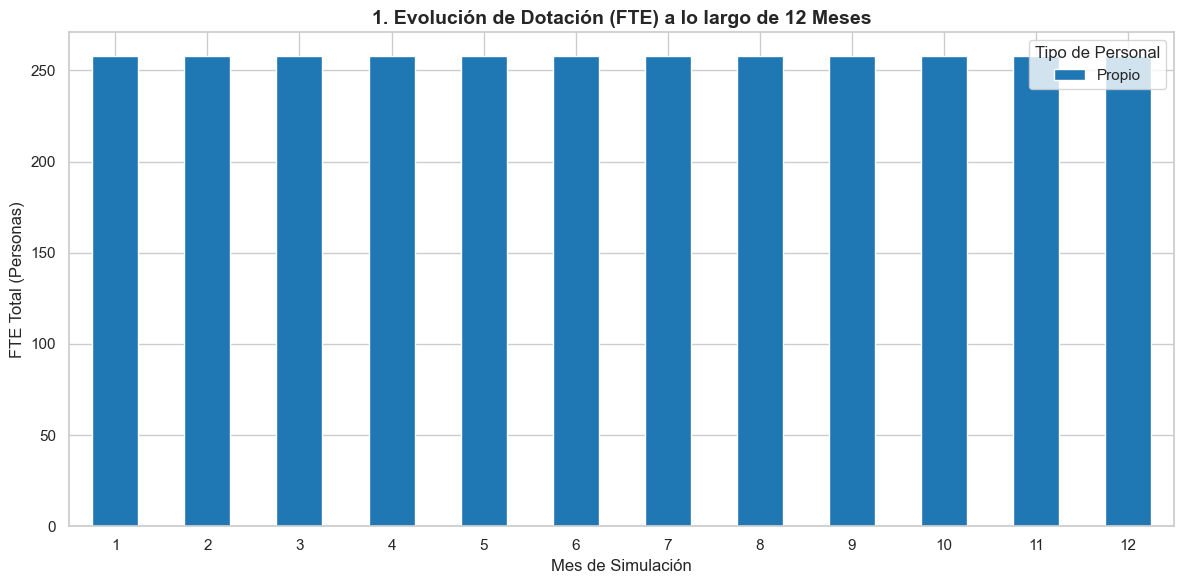

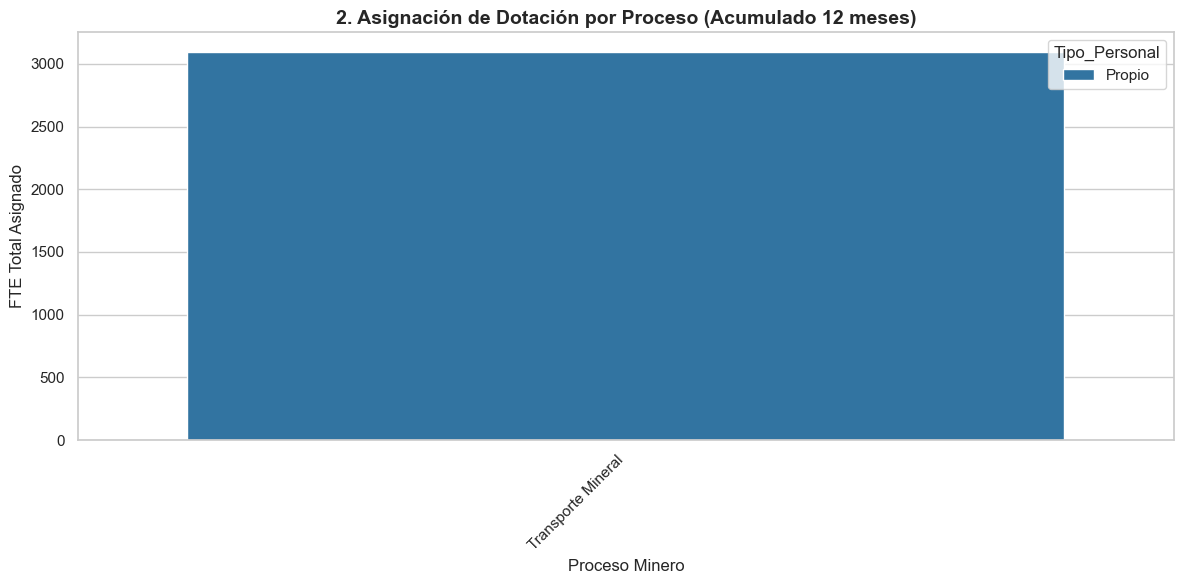

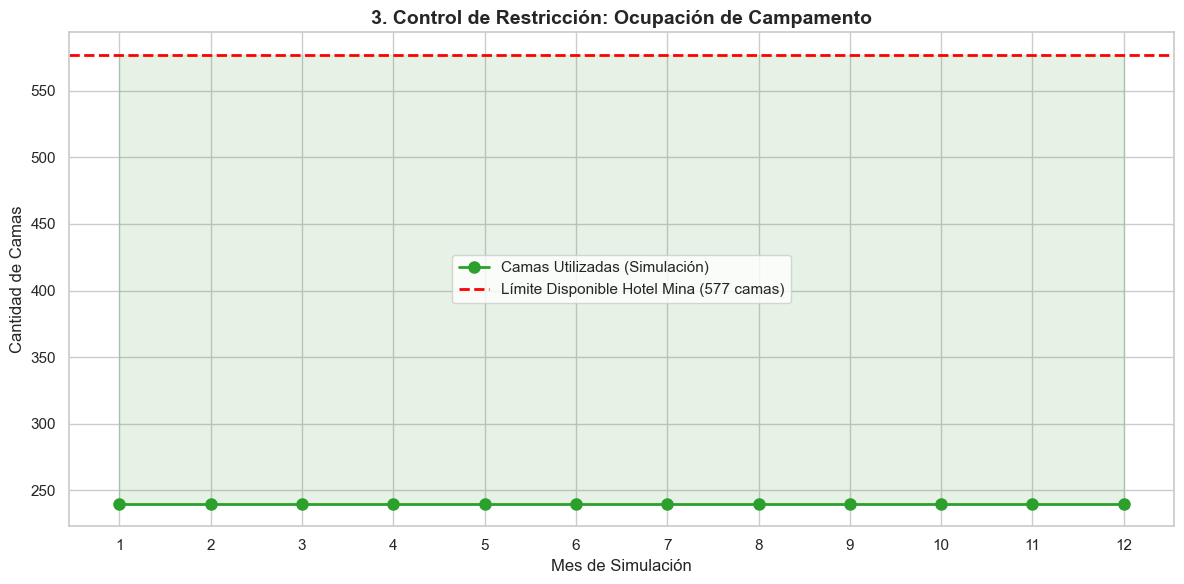

No se generó gráfico de Flota porque el modelo optimizó requiriendo 0 equipos (Revisar restricción de flota/producción si esto no es esperado).


<Figure size 1200x600 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0}) # Evitar warnings por muchas figuras

# ==============================================================================
# GRÁFICO 1: Evolución del FTE Total por Mes (Propio vs Tercero)
# ==============================================================================
plt.figure(figsize=(12, 6))
# Pivotear datos para gráfico de barras apiladas
df_pivot_fte = df_resultados.pivot_table(index='Mes', columns='Tipo_Personal', values='FTE_Simulado', aggfunc='sum').fillna(0)

# Colores institucionales (Ej: Azul para propios, Naranja/Gris para terceros)
colores = {'Propio': '#1f77b4', 'Tercero': '#ff7f0e'}
colores_usados = [colores.get(col) for col in df_pivot_fte.columns]

df_pivot_fte.plot(kind='bar', stacked=True, figsize=(12, 6), color=colores_usados)
plt.title('1. Evolución de Dotación (FTE) a lo largo de 12 Meses', fontsize=14, fontweight='bold')
plt.xlabel('Mes de Simulación', fontsize=12)
plt.ylabel('FTE Total (Personas)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Tipo de Personal')
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 2: Distribución de FTE por Proceso (Acumulado)
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultados, x='Proceso', y='FTE_Simulado', hue='Tipo_Personal', estimator=sum, errorbar=None, palette=colores)
plt.title('2. Asignación de Dotación por Proceso (Acumulado 12 meses)', fontsize=14, fontweight='bold')
plt.xlabel('Proceso Minero', fontsize=12)
plt.ylabel('FTE Total Asignado', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 3: Uso de Camas vs Capacidad del Campamento (Hotel Mina)
# ==============================================================================
# Calcular total de FTE por mes (Aplicando los factores alfa y beta del apunte)
# Como alpha y beta eran 1.0, es la suma directa, pero lo hacemos formal:
df_camas = df_resultados.copy()
df_camas['Uso_Camas'] = df_camas.apply(lambda row: row['FTE_Simulado'] * alpha if row['Tipo_Personal'] == 'Propio' else row['FTE_Simulado'] * beta, axis=1)
uso_mensual_camas = df_camas.groupby('Mes')['Uso_Camas'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(uso_mensual_camas['Mes'], uso_mensual_camas['Uso_Camas'], marker='o', linewidth=2, markersize=8, label='Camas Utilizadas (Simulación)', color='#2ca02c')
plt.axhline(y=camas_dispo_hotel_mina, color='red', linestyle='--', linewidth=2, label=f'Límite Disponible Hotel Mina ({camas_dispo_hotel_mina} camas)')

# Rellenar área de holgura
plt.fill_between(uso_mensual_camas['Mes'], uso_mensual_camas['Uso_Camas'], camas_dispo_hotel_mina, where=(camas_dispo_hotel_mina > uso_mensual_camas['Uso_Camas']), color='green', alpha=0.1, interpolate=True)
plt.fill_between(uso_mensual_camas['Mes'], uso_mensual_camas['Uso_Camas'], camas_dispo_hotel_mina, where=(camas_dispo_hotel_mina < uso_mensual_camas['Uso_Camas']), color='red', alpha=0.3, interpolate=True)

plt.title('3. Control de Restricción: Ocupación de Campamento', fontsize=14, fontweight='bold')
plt.xlabel('Mes de Simulación', fontsize=12)
plt.ylabel('Cantidad de Camas', fontsize=12)
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 4: Evolución de Flota Asignada
# ==============================================================================
plt.figure(figsize=(12, 6))
# Solo graficar si hay equipos > 0 para evitar gráficos vacíos
if df_resultados['Flota_Asignada'].sum() > 0:
    sns.lineplot(data=df_resultados, x='Mes', y='Flota_Asignada', hue='Proceso', marker='s', linewidth=2)
    plt.title('4. Requerimiento de Flota de Equipos por Mes', fontsize=14, fontweight='bold')
    plt.xlabel('Mes de Simulación', fontsize=12)
    plt.ylabel('Cantidad de Equipos Activos', fontsize=12)
    plt.xticks(range(1, 13))
    plt.legend(title='Proceso Minero')
    plt.tight_layout()
    plt.show()
else:
    print("No se generó gráfico de Flota porque el modelo optimizó requiriendo 0 equipos (Revisar restricción de flota/producción si esto no es esperado).")